# ID3 Tree Viewer

This notebook loads a tree from JSON and draws it with `matplotlib`.
It is currently configured to show `arvore_iris_fold_1.json`.

In [9]:
import json
from pathlib import Path

import matplotlib.pyplot as plt

In [10]:
TREE_PATH = Path("arvore_iris_fold_1.json")

with TREE_PATH.open(encoding="utf-8") as f:
    tree = json.load(f)

tree

{'petalwidth': {'petalwidth_bin_0': 'Iris-setosa',
  'petalwidth_bin_3': 'Iris-virginica',
  'petalwidth_bin_1': {'sepalwidth': {'sepalwidth_bin_2': 'Iris-setosa',
    'sepalwidth_bin_0': 'Iris-versicolor',
    'sepalwidth_bin_3': 'Iris-setosa',
    'sepalwidth_bin_1': 'Iris-versicolor'}},
  'petalwidth_bin_2': {'petallength': {'petallength_bin_3': 'Iris-virginica',
    'petallength_bin_1': 'Iris-versicolor',
    'petallength_bin_2': {'sepallength': {'sepallength_bin_1': 'Iris-versicolor',
      'sepallength_bin_2': {'sepalwidth': {'sepalwidth_bin_2': 'Iris-versicolor',
        'sepalwidth_bin_0': 'Iris-versicolor',
        'sepalwidth_bin_1': 'Iris-versicolor'}},
      'sepallength_bin_3': 'Iris-versicolor',
      'sepallength_bin_0': 'Iris-virginica'}}}}}}

In [11]:
def count_leaves(node):
    if not isinstance(node, dict):
        return 1

    root_attr = next(iter(node))
    return sum(count_leaves(child) for child in node[root_attr].values())


def max_depth(node):
    if not isinstance(node, dict):
        return 0

    root_attr = next(iter(node))
    children = list(node[root_attr].values())
    if not children:
        return 1
    return 1 + max(max_depth(child) for child in children)


def draw_tree(ax, node, x_min, x_max, y, y_step):
    x_center = (x_min + x_max) / 2

    if not isinstance(node, dict):
        ax.text(
            x_center,
            y,
            str(node),
            ha="center",
            va="center",
            bbox=dict(boxstyle="round,pad=0.3", fc="#d9f2d9", ec="#2e7d32", lw=1.2),
            fontsize=10,
        )
        return x_center

    root_attr = next(iter(node))
    children = node[root_attr]

    ax.text(
        x_center,
        y,
        str(root_attr),
        ha="center",
        va="center",
        bbox=dict(boxstyle="round,pad=0.35", fc="#dbeafe", ec="#1d4ed8", lw=1.4),
        fontsize=10,
        fontweight="bold",
    )

    total_leaves = count_leaves(node)
    current_x = x_min

    for edge_label, child in children.items():
        child_leaves = count_leaves(child)
        child_width = (x_max - x_min) * (child_leaves / total_leaves)
        child_x_min = current_x
        child_x_max = current_x + child_width
        child_x = draw_tree(ax, child, child_x_min, child_x_max, y - y_step, y_step)

        ax.plot([x_center, child_x], [y - 0.03, y - y_step + 0.03], color="#6b7280", lw=1.1)
        label_x = (x_center + child_x) / 2
        label_y = (y + (y - y_step)) / 2
        ax.text(label_x, label_y, str(edge_label), ha="center", va="center", fontsize=8, color="#374151")

        current_x += child_width

    return x_center

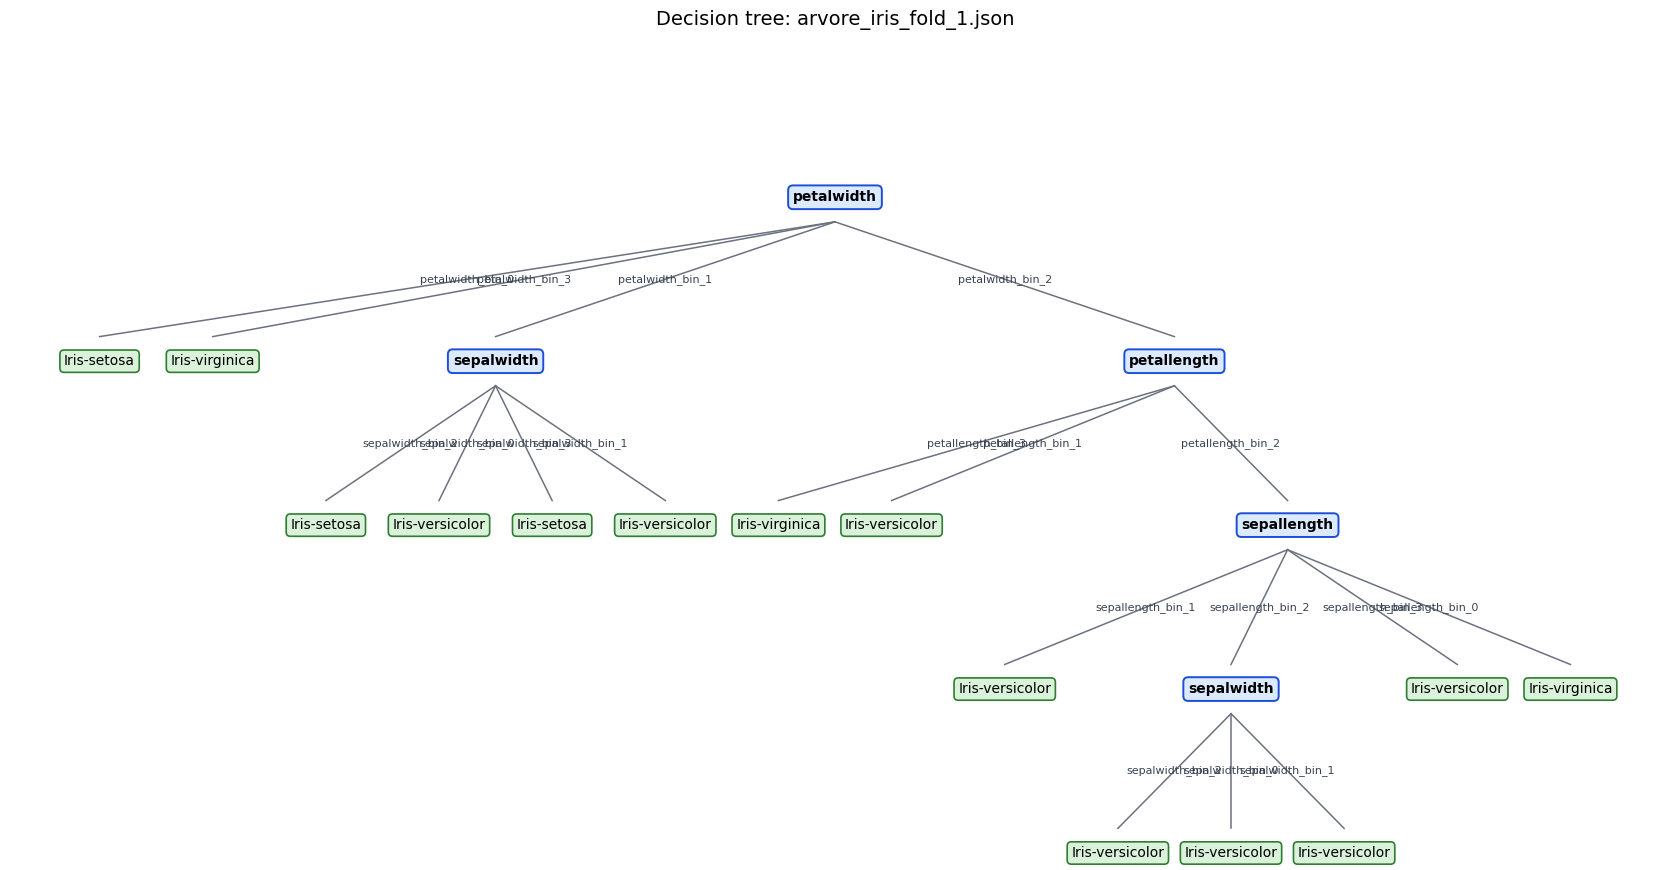

In [12]:
depth = max_depth(tree)
leaves = count_leaves(tree)

fig_width = max(12, leaves * 1.2)
fig_height = max(6, depth * 2.2)

fig, ax = plt.subplots(figsize=(fig_width, fig_height))
y_step = 1 / (depth + 1)

draw_tree(ax, tree, 0.02, 0.98, 1 - y_step, y_step)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
ax.set_title(f"Decision tree: {TREE_PATH.name}", fontsize=14)
plt.tight_layout()
plt.show()